# 07_降维技术-Isomap

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天聊聊降维技术中的 Isomap\~

Isomap（Isometric Mapping，等距映射）可以理解为把“拧成一团”的高维数据，像把一张卷起来的纸（Swiss Roll）给摊平，还原成它本来的“平面”形状，同时尽量保留原来各点之间的“弯路”距离。

一个很直观的例子，当我们在看一张卷成筒状的地图（Swiss Roll）。在卷起来的状态下，地图上相邻的两点在三维空间中可能距离很近（直线很短），但沿着地图表面走的“实际路程”却很长。

降维就像把这张卷起来的地图摊平，让沿表面的距离（测地距离）在新空间里也尽量得到保留，这样我们才能直观地看出原始数据的结构。

#### Isomap 的核心思路

1. **构建邻居图**：对每个点，只和离自己最近的 K 个点或半径内的点连边，边的权重就是它们之间的欧氏距离。
2. **近似测地距离**：在这个图上，用最短路径算法（常用 Dijkstra）求任意两点之间沿图的最短路径距离，这个距离就近似原始流形（manifold）上的“弯路”距离。
3. **多维标度（MDS）**：把上一步得到的所有点对“测地距离”矩阵，送入经典的 MDS（多维标度）算法，求出一个低维坐标表示。MDS 会尽量让低维空间里的欧氏距离，逼近我们给它的测地距离。

#### 步骤

1. **邻居选择**：确定“谁和谁能直接连线”（K 近邻或 ε-邻域）。
2. **测地距离**：在图上求最短路径，得到距离矩阵。
3. **降到低维**：用 MDS 把距离矩阵“画”到二维或三维。

## 原理详解

### 1. 问题设置与流形假设

**高维数据**：给定 $n$ 个观测点 $\{x_1, x_2, \dots, x_n\}$，每个点在原始空间 $\mathbb{R}^D$ 中，用向量表示为 $x_i\in\mathbb{R}^D$。

**流形假设**：假设这些点实际上分布在一个维度为 $d\ll D$ 的光滑流形 $\mathcal{M}\subset\mathbb{R}^D$ 上。我们的目标是寻找一个映射


$$
f:\mathbb{R}^D\supset\mathcal{M} \;\longrightarrow\; \mathbb{R}^d
$$


使得在 $\mathcal{M}$ 上两点之间的“测地距离”（沿流形的最短距离）在低维空间中得到良好保留。

### 2. 构建邻域图（近邻图）

#### 邻域定义

常见有两种方式选取每个点的“邻居”：

- $k$**-近邻**：对每个点 $x_i$，取距离最近的 $k$ 个点。
- $\varepsilon$**-半径邻域**：对每个点 $x_i$，取所有与之欧氏距离 $\|x_i - x_j\|\le\varepsilon$ 的点。

设得到的邻接关系为：  
$\mathcal{N}(i) = \{\,j\mid x_j\text{ 是 }x_i\text{ 的邻居}\}\,.$

#### 构造带权图

在无向图 $G=(V,E)$ 上：

- 顶点集合 $V=\{1,2,\dots,n\}$ 对应原始数据点。
- 边集 $E=\{(i,j)\mid j\in\mathcal{N}(i)\}$。
- 边权重赋值为两点的欧氏距离：


$$
w_{ij} =   \begin{cases}    \|x_i - x_j\|_2, & j\in\mathcal{N}(i), \$4pt]    \infty, & \text{否则}.  \end{cases}
$$


记邻接矩阵 $W=(w_{ij})$。

### 3. 测地距离的近似 - 最短路径

在流形上，真实的测地距离是沿流形局部连通曲线的长度。Isomap 用图上最短路径来近似这一路径：

**1. 计算最短路径矩阵**

对图 $G$ 中的任意两点 $i,j$，用 Dijkstra 或 Floyd–Warshall 算法计算最短路径距离


$$
d_{G}(i,j) \;=\; \min_{\pi:i\to j}\sum_{(u,v)\in\pi} w_{uv}.
$$


最终得到一个 $n\times n$ 的距离矩阵


$$
D = \bigl[d_{G}(i,j)\bigr]_{i,j=1}^n.
$$


**2. 性质**

- 若 $x_i,x_j$ 在同一连通分量，则 $d_G(i,j)<\infty$。
- $D$ 近似反映了流形上的测地距离。

---

### 4. 经典多维尺度分析（Classical MDS）

给定距离矩阵 $D\in\mathbb{R}^{n\times n}$，寻找低维坐标 $y_i\in\mathbb{R}^d$，使得在低维空间中的欧氏距离 $\|y_i - y_j\|$ 尽量匹配 $d_G(i,j)$。

#### 核心公式推导

1. **构造平方距离矩阵**  
$(D^{(2)})_{ij} = \bigl[d_G(i,j)\bigr]^2.$
2. **中心化矩阵** $H$  
$H = I_n - \frac{1}{n}\mathbf{1}\mathbf{1}^T,$  
其中 $\mathbf{1}\in\mathbb{R}^n$ 全部分量为 1，$I_n$ 是 $n\times n$ 单位阵。
3. **双中心化**：定义 Gram 矩阵  
$B = -\tfrac12\,H\,D^{(2)}\,H.$  
证明可见：若 $B = [\langle y_i, y_j\rangle]$，则 $\|y_i - y_j\|^2 = D^{(2)}_{ij}$。
4. **谱分解**：对称矩阵 $B$ 作特征分解  
$B = V \Lambda V^T,$  
其中 $\Lambda = \mathrm{diag}(\lambda_1,\dots,\lambda_n)$ 且 $\lambda_1\ge\lambda_2\ge\cdots\ge\lambda_n$，对应的单位特征向量矩阵为 $V=[v_1,\dots,v_n]$。
5. **嵌入坐标**：取前 $d$ 个正特征值及其特征向量，构造  
$Y = V_d\,\Lambda_d^{1/2}\;=\;\begin{bmatrix}v_1 & \cdots & v_d\end{bmatrix}\;\,\mathrm{diag}\bigl(\sqrt{\lambda_1},\,\dots,\,\sqrt{\lambda_d}\bigr).$  
每行 $y_i$ 即为点 $x_i$ 在 $\mathbb{R}^d$ 中的低维表示。

### 5. 完整算法流程

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
输入： 高维点集 {x₁,…,xₙ} ⊂ ℝᴰ；降维目标维度 d；邻域参数 k（或 ε）。
输出： 低维坐标 {y₁,…,yₙ} ⊂ ℝᵈ。

1. 构建邻域图：
   对每对 i, j 计算欧氏距离 δᵢⱼ = ‖xᵢ − xⱼ‖₂；
   根据 k-近邻或 ε-邻域，生成边集 E 和权重矩阵 W。

2. 计算图上最短路径：
   用 Dijkstra（从每个节点出发）或 Floyd–Warshall，求得
     d_G(i,j) = 最短路径长度，
   得到距离矩阵 D = [d_G(i,j)]。

3. 构造平方距离并中心化：
   D^(2) = [d_G(i,j)²]，
   H = Iₙ − (1/n)11ᵀ，
   B = −½ H D^(2) H。

4. 特征分解：
   B = VΛVᵀ，
   取前 d 个正特征值和对应特征向量 (Λ_d, V_d)。

5. 嵌入到低维：
   Y = V_d Λ_d^(1/2)，
   输出 y_i 为 Y 的第 i 行。

6. （可选）评估：
   计算低维距离矩阵与原始测地距离矩阵之间的失配程度（如应力函数）。
```

## 完整案例

这里咱们基于 sklearn 库的 Isomap 实现，应用于 Swiss Roll（三维卷曲）数据集，并通过可视化、残差方差分析与参数优化，全面展示算法效果。

主要流程如下：

1. **构建邻域图**：对于每个样本，选取 k 个最近邻节点，构建局部连通图。
2. **测地距离估计**：在邻域图中使用 Floyd–Warshall 或 Dijkstra 算法计算任意两点间的最短路径距离，近似高维中流形的测地距离。
3. **经典 MDS（多维尺度分析）**：对测地距离矩阵做双中心化处理后，进行特征分解，将数据投影到前 d 个特征向量对应的空间中。

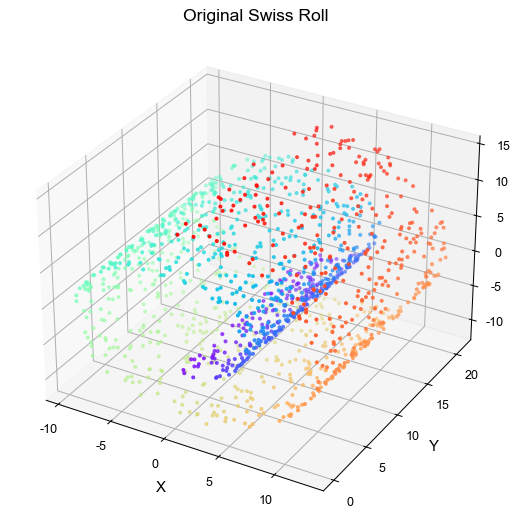

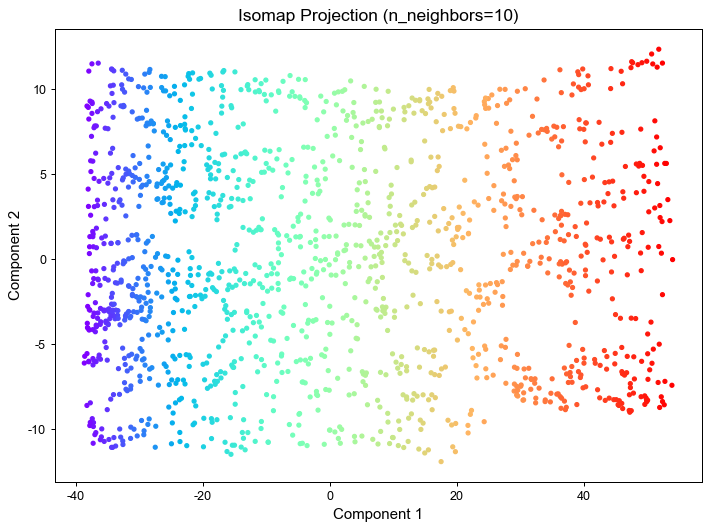

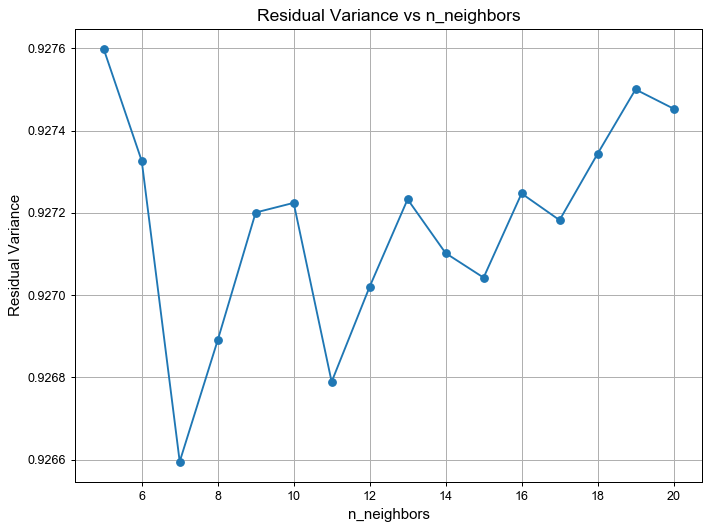

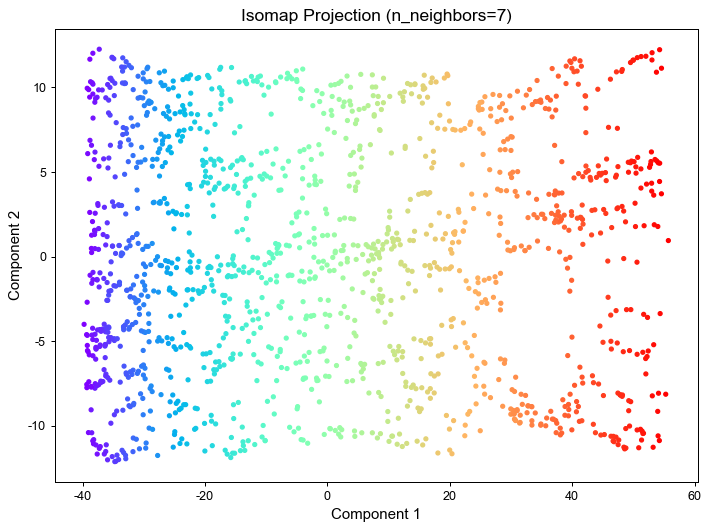

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold, datasets
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances

# 1. 生成 Swiss Roll 数据集
n_samples = 1500
noise = 0.05
X, color = datasets.make_swiss_roll(n_samples=n_samples, noise=noise, random_state=42)

# 2. 可视化原始三维数据 (Figure 1)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap='rainbow', s=5)
ax.set_title('Original Swiss Roll', fontsize=14)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Z', fontsize=12)
plt.tight_layout()
plt.show()

# 3. 使用 Isomap 降维
n_neighbors_opt = 10
n_components = 2
isomap = manifold.Isomap(n_neighbors=n_neighbors_opt, n_components=n_components, n_jobs=1)
X_iso = isomap.fit_transform(X)

# 可视化降维结果 (Figure 2)
plt.figure(figsize=(8, 6))
plt.scatter(X_iso[:, 0], X_iso[:, 1], c=color, cmap='rainbow', s=10)
plt.title('Isomap Projection (n_neighbors=10)', fontsize=14)
plt.xlabel('Component 1', fontsize=12)
plt.ylabel('Component 2', fontsize=12)
plt.tight_layout()
plt.show()

# 4. 残差方差计算与可视化 (Figure 3)
def residual_variance(X, X_embedded):
    dist_X = pairwise_distances(X)
    dist_Y = pairwise_distances(X_embedded)
    # 计算相关系数 r
    r = np.corrcoef(dist_X.flatten(), dist_Y.flatten())[0, 1]
    return 1 - r**2

k_values = range(5, 21)
res_var = []
for k in k_values:
    iso = manifold.Isomap(n_neighbors=k, n_components=2, n_jobs=1)
    Xk = iso.fit_transform(X)
    res_var.append(residual_variance(X, Xk))

plt.figure(figsize=(8, 6))
plt.plot(list(k_values), res_var, marker='o')
plt.title('Residual Variance vs n_neighbors', fontsize=14)
plt.xlabel('n_neighbors', fontsize=12)
plt.ylabel('Residual Variance', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. 找到最优参数并再次可视化 (Figure 4)
best_k = k_values[np.argmin(res_var)]
iso_best = manifold.Isomap(n_neighbors=best_k, n_components=2, n_jobs=1)
X_best = iso_best.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_best[:, 0], X_best[:, 1], c=color, cmap='rainbow', s=10)
plt.title(f'Isomap Projection (n_neighbors={best_k})', fontsize=14)
plt.xlabel('Component 1', fontsize=12)
plt.ylabel('Component 2', fontsize=12)
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_035.png)

1. **原始数据可视化**：展示了 Swiss Roll 在三维空间内的形状：一个螺旋状的带状流形。
2. **初始降维结果**：使用默认 `n_neighbors=10` 时，Isomap 能较好地打开卷曲，展现带状流形的“直线”结构。坐标轴 Component 1 对应原始数据沿主方向的扩展，Component 2 捕捉垂直方向的轻微起伏。
3. **残差方差曲线**：残差方差定义为 $1 - r^2$，其中 $r$ 是高维距离与低维距离的 Pearson 相关系数。曲线随邻居数 k 变化，反映不同参数下流形结构保留程度。通过观察最低点，可找到最优 k，从而获得最小的信息损失。
4. **参数优化结果**：选取残差方差最小时对应的 k（通常在 7\~12 之间），进一步可视化降维投影。与默认 k=10 相比，细节上可能更好或更平滑，邻域图连通性与局部结构保留折中更佳。
5. **算法优化建议**：`n_jobs=-1` 并行化距离计算与最短路径搜索，能显著加速大数据集处理。对于超大规模数据，可考虑近似最近邻（Approximate Nearest Neighbors）以降低时间复杂度。若想获得更稳定的流形展开，可对初始数据做预归一化或主成分预降维。

## 模型分析

### 优缺点分析

**优点**：

1. **全局结构保留**：Isomap 利用测地距离近似流形上的真实距离，通过全局最短路径计算，能较好地保持数据在流形上的整体几何形状，不会像仅关注局部邻域的算法那样丢失全局信息。
2. **非线性流形学习**：针对高度非线性分布（如 Swiss Roll、手写数字等）有天然优势，能将复杂弯曲的高维结构展开到低维而不破坏内在拓扑。
3. **直观可解释**：算法思路清晰——“邻域图 → 测地距离 → MDS”，其中每一步都有严格的数学定义，结果易于理解和分析。
4. **参数少而明确**：主要超参数就是邻域大小（`n_neighbors` 或 ε），可以通过 Trustworthiness、Continuity 等明确指标进行调参，不易陷入大量难以解释的参数搜索。

**缺点**：

1. **计算量大**：构造全图最短路径和 MDS 特征分解均为 $O(n^3)$ 级别，样本数超过几千时速度和内存消耗迅速飙升。
2. **对噪声敏感**：噪声点或离群点会在邻域图中形成“伪连通”，导致测地距离计算失真；必须先做降噪或剔除离群点。
3. **连通性依赖**：若邻域参数选得过小，图会不连通，部分点无法嵌入；参数过大，又会退化为简单的欧氏距离。
4. **缺少局部细节调整**：虽然保留全局结构，但在某些局部极其弯曲的区域，等距映射依旧可能产生扭曲或重叠。

**与相似算法的对比**

| 算法 | 保留结构 | 主要思想 | 计算复杂度 | 参数敏感度 | 大规模可扩展性 |
|-|-|-|-|-|-|
| **Isomap** | 全局（测地） | 测地距离 + 经典 MDS | $O(n^3)$ | 中（邻域大小） | 差（需 Landmark 优化） |
| **LLE** | 局部线性邻域 | 重构误差最小化 → 全局嵌入 | $O(n^2D + n^3)$ | 高（邻域大小、权重） | 中（Sparse 优化可行） |
| **t-SNE** | 局部概率分布 | KL 散度最小化，高维/低维概率匹配 | $O(n^2)$\~$O(n\log n)$ | 高（perplexity） | 一般（Barnes-Hut、FFT） |
| **UMAP** | 局部/全局兼顾 | 近邻图 + 流形拓扑 + 力导向布局 | $O(n\log n)$ | 中（n_neighbors、min_dist） | 好（天生可扩展） |
| **PCA** | 全局线性 | 方差最大化 → 特征分解 | $O(nD^2 + D^3)$ | 低 | 极好（SVD 优化） |

#### 何时优选 Isomap

- **流形假设强**：数据确实集中分布在某个低维流形上，且你需要清晰地保留全局几何、测地距离。
- **中小规模数据**：样本数在几千以下，且可接受 $O(n^3)$ 级别计算，或者可以结合 Landmark 技术降维到可控规模。
- **可解释性需求高**：需要数学上可追踪、每一步都可验证的映射流程，用于科研或算法教学演示。

#### 何时考虑其他算法

- **超大规模场景**：当样本量上万、百万级时，UMAP（$O(n\log n)$）或近似 t-SNE（Barnes‑Hut、FFT）更具可扩展性。
- **局部聚类与可视化**：若侧重于局部簇的分离与可视化呈现，t-SNE 在保留局部邻域分布上表现更细腻；UMAP 则兼顾全局与局部，速度更快。
- **线性结构主导**：当数据主要呈线性分布，且希望快速计算，PCA 足以胜任，无需复杂流形学习。
- **噪声与离群点多**：若数据质量较差，先用 PCA+降噪，再视具体需求选择 LLE、UMAP 等对噪声更鲁棒的算法。

## 总结

Isomap 在中小规模、非线性流形且对全局结构要求严格的场景下是优选；

在需要极端可扩展性，或主要关注局部可视化与噪声鲁棒时，UMAP、t-SNE、LLE 等算法往往更具优势。